# Putting a number on it: ONI vs. your sea level record

Yesterday you built monthly sea level for your station and drew the big El Niño
winters over the seasonal cycle. Your eyes said the warm events ride high. Today
we test that against NOAA's standard yardstick for El Niño strength: the
**Oceanic Niño Index (ONI)**, the 3-month running mean of sea surface temperature
anomaly in the Niño 3.4 box (5°N–5°S, 120°–170°W). Five consecutive seasons at or
above +0.5 °C is the official definition of an El Niño event; at or below
−0.5 °C, La Niña.

The plan, with x = ONI and y = your station's sea level:

1. form monthly averages of y
2. remove the seasonal cycle from y (subtract the average of all Januarys from
   each January, and so on)
3. remove the trend from y
4. overlay time series of x and y
5. scatter plot x vs. y
6. compute the correlation

One given cell sits between steps 1 and 2: as in notebook 11, it splices NOAA
CO-OPS monthly means onto the end of the UHSLC record, so every station reaches
the present and the 2026–27 event counts in your correlation.

This is the instructor version: every step is complete and executed for San
Diego, and section 12 runs the full ten-station transect. The student version
scaffolds steps 1–6 with hints; hand out
`notebooks/14_el_nino_oni_correlation.ipynb`.

In [1]:
import json
from pathlib import Path
from urllib.request import urlopen, urlretrieve
from urllib.error import HTTPError, URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Everything in the course runs relative to the project root, never to a
# personal path, so the same notebook works on every machine.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in ("notebooks", "reference"):
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "README.md").exists(), "Open the course project folder first."

UHSLC_RAW = PROJECT_ROOT / "data" / "raw" / "uhslc"
UHSLC_RAW.mkdir(parents=True, exist_ok=True)

## 1. The x variable: ONI

The Climate Prediction Center publishes ONI as a plain text table, one row per
overlapping 3-month season since 1950:

```
 SEAS  YR   TOTAL   ANOM
  DJF 1950  25.01  -1.32
  JFM 1950  25.36  -1.20
```

`ANOM` is the index itself. Each season is stamped here at its **center month**
(DJF is a January value, JFM February, and so on), which turns the table into an
ordinary monthly time series we can line up against sea level. This loader is
given — the construction work starts with your y variable below.

ONI: 1950-01 to 2026-06, latest value +1.39 deg C


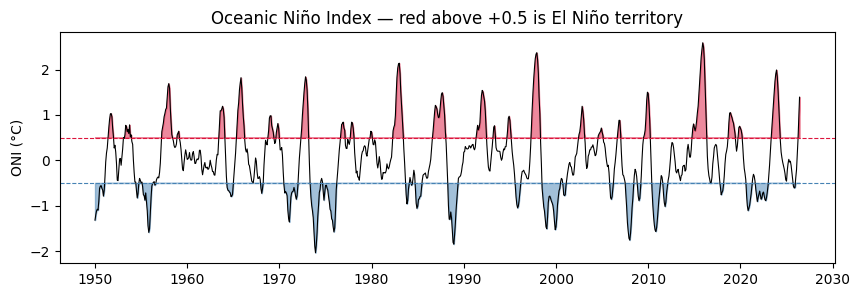

In [2]:
ONI_URL = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"

# each 3-month season, mapped to the calendar month at its center
SEASON_CENTER = {"DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4, "AMJ": 5, "MJJ": 6,
                 "JJA": 7, "JAS": 8, "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12}


def load_oni():
    """ONI as a monthly pandas Series (deg C anomaly), stamped at month start."""
    table = pd.read_csv(ONI_URL, sep=r"\s+")
    center = table["SEAS"].map(SEASON_CENTER)
    idx = pd.to_datetime(dict(year=table["YR"], month=center, day=1))
    return pd.Series(table["ANOM"].to_numpy(), index=idx, name="ONI")


oni = load_oni()
print(f"ONI: {oni.index[0]:%Y-%m} to {oni.index[-1]:%Y-%m}, "
      f"latest value {oni.iloc[-1]:+.2f} deg C")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(oni.index, oni, lw=0.8, color="k")
# the +/-0.5 degC thresholds that define El Nino / La Nina conditions
ax.axhline(0.5, color="crimson", ls="--", lw=0.8)
ax.axhline(-0.5, color="steelblue", ls="--", lw=0.8)
ax.fill_between(oni.index, 0.5, oni.clip(lower=0.5), color="crimson", alpha=0.5)
ax.fill_between(oni.index, -0.5, oni.clip(upper=-0.5), color="steelblue", alpha=0.5)
ax.set_ylabel("ONI (°C)")
ax.set_title("Oceanic Niño Index — red above +0.5 is El Niño territory")
plt.show()

## 2. The y variable: your station's daily sea level

Same data and loader as yesterday. If `data/raw/uhslc/` already has your file,
nothing downloads. Set `MY_SITE` to your group's station.

In [3]:
STATIONS = {
    # name: UHSLC daily file        record ends
    "San Diego":     "d569.nc",   # 2026 —— the in-class demo
    "La Jolla":      "d554.nc",   # 2026
    "Los Angeles":   "d567a.nc",  # 2021
    "Port San Luis": "d565a.nc",  # 2021
    "Monterey":      "d555a.nc",  # 2021
    "San Francisco": "d551.nc",   # 2026
    "Humboldt Bay":  "d576a.nc",  # 2021
    "Crescent City": "d556.nc",   # 2026
    "South Beach":   "d592.nc",   # 2026 —— Oregon: sea level only
    "Astoria":       "d572a.nc",  # 2024 —— Oregon: sea level only
}

MY_SITE = "San Diego"  # TODO: change to your group's station

UHSLC_BASE = "https://uhslc.soest.hawaii.edu/data/netcdf"
ARCHIVES = ["fast/daily", "rqds/pacific/daily"]


def fetch_station(filename):
    """Download one UHSLC daily NetCDF file into data/raw/uhslc, if not there."""
    target = UHSLC_RAW / filename
    if target.exists():
        return target  # already on disk: never re-download raw data
    for archive in ARCHIVES:
        try:
            urlretrieve(f"{UHSLC_BASE}/{archive}/{filename}", target)
            print(f"downloaded {filename} from {archive}")
            return target
        except HTTPError:
            continue
    raise FileNotFoundError(f"{filename} not found in any UHSLC archive")


def load_daily(path):
    """Daily sea level as a pandas Series in cm, plus station name and latitude."""
    with xr.open_dataset(path) as ds:
        name = ds["station_name"].values.astype(str).item()
        lat = float(ds["lat"].values.squeeze())
        daily = ds["sea_level"].squeeze("record_id", drop=True).to_series() * 0.1
    return daily, name, lat


daily, name, lat = load_daily(fetch_station(STATIONS[MY_SITE]))
print(f"{name} ({lat:.2f}°N): {daily.index[0].date()} to {daily.index[-1].date()}")

San Diego (32.71°N): 1906-01-22 to 2026-06-30


## 3. Step 1 — monthly averages

ONI is monthly, so y must be monthly too. Turn the daily series into
calendar-month means, and blank any month with fewer than 15 valid days — an
average built from a handful of days is not a trustworthy monthly mean.

**Hints:** `daily.resample("MS")` groups a daily series by calendar month
(`"MS"` stamps each group at month start, matching how we stamped ONI).
`.mean()` on the grouped object averages each month; `.count()` on the same
grouped object tells you how many real observations each month has.

In [4]:
grouped = daily.resample("MS")
monthly = grouped.mean()
monthly[grouped.count() < 15] = np.nan   # months too gappy to trust

# checkpoint: one value per calendar month, spanning the whole record
print(f"{len(monthly)} months, {monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m}, "
      f"{monthly.isna().sum()} blanked")

1446 months, 1906-01 to 2026-06, 26 blanked


## 4. Extend to the present with NOAA CO-OPS (given)

Half the transect's UHSLC files end in 2021 or 2024, but ONI runs to last month
and the 2026–27 event is in progress — months your correlation should not have
to do without. NOAA still operates every one of these gauges, so this cell (the
same splice as notebook 11) appends CO-OPS verified monthly means, plus a
provisional average of the current month, to the end of your `monthly` series.
The two sources sit on different datums; the median difference over their shared
months removes it, and the printed scatter is the sanity check — a centimeter or
so means the station pairing is right.

In [5]:
COOPS_IDS = {   # NOAA CO-OPS ids for the same gauges
    "San Diego": "9410170", "La Jolla": "9410230", "Los Angeles": "9410660",
    "Port San Luis": "9412110", "Monterey": "9413450", "San Francisco": "9414290",
    "Humboldt Bay": "9418767", "Crescent City": "9419750",
    "South Beach": "9435380", "Astoria": "9439040",
}
COOPS_API = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
TODAY = pd.Timestamp.today()


def coops_request(station_id, product, begin, end):
    """One call to the NOAA CO-OPS data API, returning the rows as a list."""
    url = (f"{COOPS_API}?product={product}&begin_date={begin}&end_date={end}"
           f"&datum=STND&station={station_id}&time_zone=GMT&units=metric&format=json")
    with urlopen(url, timeout=60) as response:
        return json.load(response).get("data", [])


def extend_with_coops(monthly, station_id, label=""):
    """Append offset-adjusted CO-OPS months after the UHSLC record ends."""
    # 1) verified monthly means since 2017 (meters on NOAA's datum -> cm)
    rows = coops_request(station_id, "monthly_mean", "20170101",
                         TODAY.strftime("%Y%m%d"))
    idx = pd.to_datetime([f"{r['year']}-{int(r['month']):02d}-01" for r in rows])
    coops = pd.Series([float(r["MSL"]) * 100 for r in rows], index=idx)

    # 2) the current month so far, from the preliminary 6-minute feed
    recent = coops_request(station_id, "water_level",
                           TODAY.strftime("%Y%m01"), TODAY.strftime("%Y%m%d"))
    values = [float(r["v"]) for r in recent if r.get("v")]
    if len(values) >= 7 * 240:  # only with at least a week of data
        coops[pd.Timestamp(TODAY.strftime("%Y-%m-01"))] = np.mean(values) * 100

    # 3) align the two sources: the datum difference is a constant, so the
    #    median difference over shared months estimates it robustly
    both = pd.concat([monthly, coops], axis=1, keys=["uhslc", "coops"]).dropna()
    offset = (both["uhslc"] - both["coops"]).median()
    print(f"{label:<16} offset {offset:+6.1f} cm over {len(both)} shared months, "
          f"scatter {(both['uhslc'] - both['coops'] - offset).std():4.1f} cm, "
          f"through {coops.index[-1]:%Y-%m}")

    # 4) keep UHSLC as-is and append only the months it doesn't have
    tail = coops[coops.index > monthly.last_valid_index()] + offset
    return pd.concat([monthly[: monthly.last_valid_index()], tail])


monthly = extend_with_coops(monthly, COOPS_IDS[MY_SITE], MY_SITE)

San Diego        offset   -0.0 cm over 114 shared months, scatter  0.1 cm, through 2026-08


## 5. Step 2 — remove the seasonal cycle

Sea level here breathes with the seasons (steric heating in summer, storms and
pressure in winter), and that cycle is as large as the El Niño signal we are
hunting. Remove it: subtract the average of all Januarys from every January, all
Februarys from every February, and so on. What survives is the **anomaly** — the
part of each month that the calendar cannot explain.

**Hints:** `monthly.index.month` gives each row's calendar month number (1–12).
`monthly.groupby(monthly.index.month)` groups by it, and `.transform("mean")`
returns those 12 group means stretched back to the full length of the series —
exactly the thing to subtract. (Yesterday's `seasonal_climatology` used the same
groupby with `.mean()`; `transform` is the same idea, shaped for subtraction.)

In [6]:
climatology = monthly.groupby(monthly.index.month).transform("mean")
anomaly = monthly - climatology

# checkpoint: the anomaly's own seasonal cycle should be zero by construction
residual_cycle = anomaly.groupby(anomaly.index.month).mean()
print(f"largest leftover monthly mean: {residual_cycle.abs().max():.2e} cm (want ~0)")

largest leftover monthly mean: 1.33e-14 cm (want ~0)


## 6. Step 3 — remove the trend

A century of relative sea level rise is still in the anomaly, and over 75 shared
years it would masquerade as correlation with anything else that drifts. Fit a
straight line against time and subtract it, exactly as yesterday.

**Hints:** build a time axis in fractional years from the index
(`anomaly.index.year + (anomaly.index.month - 0.5) / 12`). `np.polyfit(x, y, 1)`
returns slope and intercept, but cannot digest NaNs — mask them out of the fit
with `anomaly.notna()`, then subtract the fitted line from the *whole* series.
The slope is in cm/yr; multiply by 10 for mm/yr to compare with yesterday's
number.

In [7]:
years = anomaly.index.year + (anomaly.index.month - 0.5) / 12
valid = anomaly.notna()
slope, intercept = np.polyfit(years[valid], anomaly[valid], 1)
sl = anomaly - (slope * years + intercept)

# checkpoint: the trend should match what you found (and NOAA publishes) yesterday
print(f"{name} trend: {slope * 10:.1f} mm/yr; detrended series centered at "
      f"{sl.mean():+.2f} cm")

San Diego trend: 2.2 mm/yr; detrended series centered at +0.00 cm


## 7. Step 4 — overlay the two time series

Now look before you compute. ONI is in °C and sea level in cm, so give each its
own y-axis and let the shapes do the talking.

**Hints:** `ax2 = ax.twinx()` makes a second y-axis sharing the same time axis.
Plot ONI on one, `sl` on the other, in different colors, and restrict the view to
1950 onward (`sl["1950":]`) since that is where ONI begins. Where are 1982–83,
1997–98, 2015–16, 2023–24 in each curve?

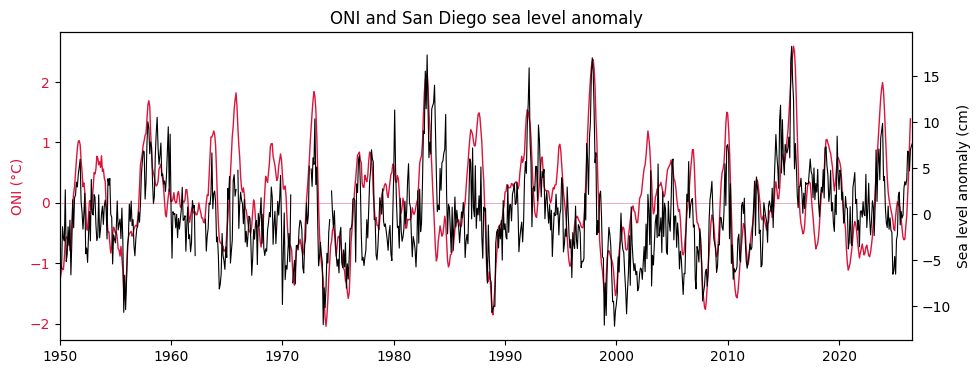

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(oni.index, oni, color="crimson", lw=1, label="ONI")
ax.axhline(0, color="crimson", lw=0.5, alpha=0.5)
ax.set_ylabel("ONI (°C)", color="crimson")
ax.tick_params(axis="y", labelcolor="crimson")

ax2 = ax.twinx()
ax2.plot(sl["1950":].index, sl["1950":], color="k", lw=0.8,
         label="sea level anomaly")
ax2.set_ylabel("Sea level anomaly (cm)")

ax.set_xlim(pd.Timestamp("1950-01-01"), sl.index[-1])
ax.set_title(f"ONI and {name} sea level anomaly")
plt.show()

## 8. Step 5 — the scatter plot

The overlay shows *when* the two move together; the scatter shows *how much*, one
point per shared month.

**Hints:** the two series have different spans and gaps, so align them first:
`pd.concat([oni, sl.rename("sl")], axis=1).dropna()` keeps exactly the months
where both exist. With ~900 points, `ax.scatter(..., s=8, alpha=0.4)` keeps the
cloud readable.

904 shared months, 1950-01 to 2026-06


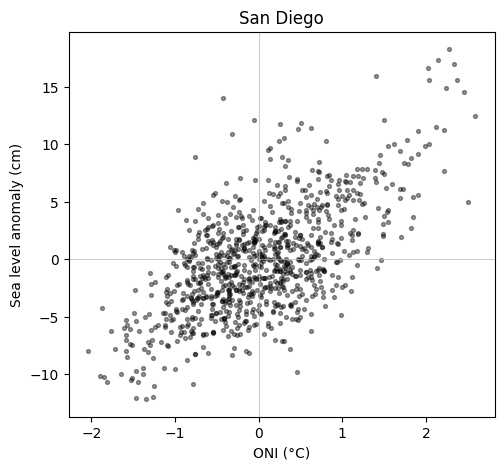

In [9]:
both = pd.concat([oni, sl.rename("sl")], axis=1).dropna()
print(f"{len(both)} shared months, {both.index[0]:%Y-%m} to {both.index[-1]:%Y-%m}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(both["ONI"], both["sl"], s=8, alpha=0.4, color="k")
ax.axhline(0, color="0.7", lw=0.5)
ax.axvline(0, color="0.7", lw=0.5)
ax.set_xlabel("ONI (°C)")
ax.set_ylabel("Sea level anomaly (cm)")
ax.set_title(name)
plt.show()

## 9. Step 6 — the correlation

One number for the board.

**Hints:** `both["ONI"].corr(both["sl"])` gives Pearson's r (it ignores nothing —
you already dropped the gaps). While you are at it, `np.polyfit` on the two
columns gives the regression slope: cm of sea level per °C of ONI, a number with
physical units your neighbors can compare.

In [10]:
r = both["ONI"].corr(both["sl"])
slope_cm_per_degC = np.polyfit(both["ONI"], both["sl"], 1)[0]
print(f"{name}: r = {r:.2f}  (r² = {r**2:.2f}), "
      f"{slope_cm_per_degC:.1f} cm per °C of ONI")

San Diego: r = 0.65  (r² = 0.42), 3.9 cm per °C of ONI


## 10. Interpret

**For the class board:** station, latitude, r, r², and the regression slope
(cm/°C). Then, as a group:

1. Is the correlation positive or negative, and what physics carries a warm
   tropical Pacific to sea level at *your* latitude? (Think back to this
   morning: coastally trapped waves, thermosteric warming, and the shifted storm
   track are all candidates.)
2. r² is the fraction of monthly variance ONI explains. What is doing the rest?
3. Look at the scatter's outliers — months far off the trend. Pick one, find its
   date in `both`, and check what was happening (a storm? a gap?).
4. Prediction before the board fills in: will r grow, shrink, or hold as the
   stations march north from San Diego to Astoria?

## 11. If you finish early

- **Match the smoothing.** ONI is a 3-month running mean but your y is raw
  monthly. Smooth it the same way
  (`sl.rolling(3, center=True, min_periods=2).mean()`) and recompute r. For San
  Diego this lifts r from 0.65 to 0.70 — why should matching the smoothing help?
- **Lead or lag?** `oni.shift(k)` moves ONI k months later. Loop k from −6 to +6
  and find where r peaks. Does the ocean here respond to the tropics instantly,
  or late?
- **Waves too?** Notebook 12 gave you a monthly wave record. Does ONI correlate
  with wave energy at your station the way it does with sea level?

## 12. The whole transect (instructor)

The class board, precomputed: the same six steps for all ten stations, each
record extended to the present. The offset table doubles as the CO-OPS health
check; a station whose splice fails falls back to its UHSLC record with a
printed warning.

In [11]:
def analyze(site):
    """Steps 1-6 for one station. Returns everything the plots below need."""
    daily, name, lat = load_daily(fetch_station(STATIONS[site]))
    grouped = daily.resample("MS")
    monthly = grouped.mean()
    monthly[grouped.count() < 15] = np.nan
    try:
        monthly = extend_with_coops(monthly, COOPS_IDS[site], site)
    except (HTTPError, URLError, TimeoutError) as err:
        print(f"{site:<16} CO-OPS unavailable ({err}); UHSLC record only")
    climatology = monthly.groupby(monthly.index.month).transform("mean")
    anomaly = monthly - climatology
    years = anomaly.index.year + (anomaly.index.month - 0.5) / 12
    valid = anomaly.notna()
    slope, intercept = np.polyfit(years[valid], anomaly[valid], 1)
    sl = anomaly - (slope * years + intercept)
    both = pd.concat([oni, sl.rename("sl")], axis=1).dropna()
    return {"site": site, "name": name, "lat": lat, "sl": sl, "both": both,
            "trend": slope * 10, "r": both["ONI"].corr(both["sl"]),
            "cm_per_degC": np.polyfit(both["ONI"], both["sl"], 1)[0]}


records = [analyze(site) for site in STATIONS]

print(f"\n{'station':<16} {'lat':>6} {'months':>7} {'trend':>6} "
      f"{'r':>6} {'r²':>5} {'cm/°C':>6}")
for rec in records:
    print(f"{rec['site']:<16} {rec['lat']:>6.2f} {len(rec['both']):>7} "
          f"{rec['trend']:>6.1f} {rec['r']:>6.2f} {rec['r'] ** 2:>5.2f} "
          f"{rec['cm_per_degC']:>6.1f}")

San Diego        offset   -0.0 cm over 114 shared months, scatter  0.1 cm, through 2026-08


La Jolla         offset   +0.0 cm over 113 shared months, scatter  0.1 cm, through 2026-08


Los Angeles      offset   +0.0 cm over 60 shared months, scatter  0.1 cm, through 2026-08


Port San Luis    offset   +0.0 cm over 60 shared months, scatter  0.1 cm, through 2026-08


Monterey         offset   +0.0 cm over 60 shared months, scatter  0.1 cm, through 2026-08


San Francisco    offset   -0.0 cm over 107 shared months, scatter  0.2 cm, through 2026-08


Humboldt Bay     offset   -0.0 cm over 60 shared months, scatter  0.2 cm, through 2026-08


Crescent City    offset   -0.0 cm over 114 shared months, scatter  0.2 cm, through 2026-08


South Beach      offset   -0.1 cm over 110 shared months, scatter  0.5 cm, through 2026-08


Astoria          offset   -0.0 cm over 96 shared months, scatter  0.2 cm, through 2026-08

station             lat  months  trend      r    r²  cm/°C
San Diego         32.71     904    2.2   0.65  0.42    3.9
La Jolla          32.87     883    2.0   0.63  0.40    3.8
Los Angeles       33.72     909    1.1   0.63  0.40    3.6
Port San Luis     35.18     839    1.1   0.57  0.33    3.8
Monterey          36.60     631    1.9   0.63  0.39    4.0
San Francisco     37.81     913    2.0   0.51  0.26    4.0
Humboldt Bay      40.77     579    5.0   0.49  0.24    4.2
Crescent City     41.74     884   -0.8   0.43  0.18    3.8
South Beach       44.62     706    1.5   0.34  0.12    3.4
Astoria           46.21     915   -0.2   0.20  0.04    2.3


The overlays, south to north. Sea level (black, left axis, one shared scale)
with ONI (red, right axis) repeated in every panel.

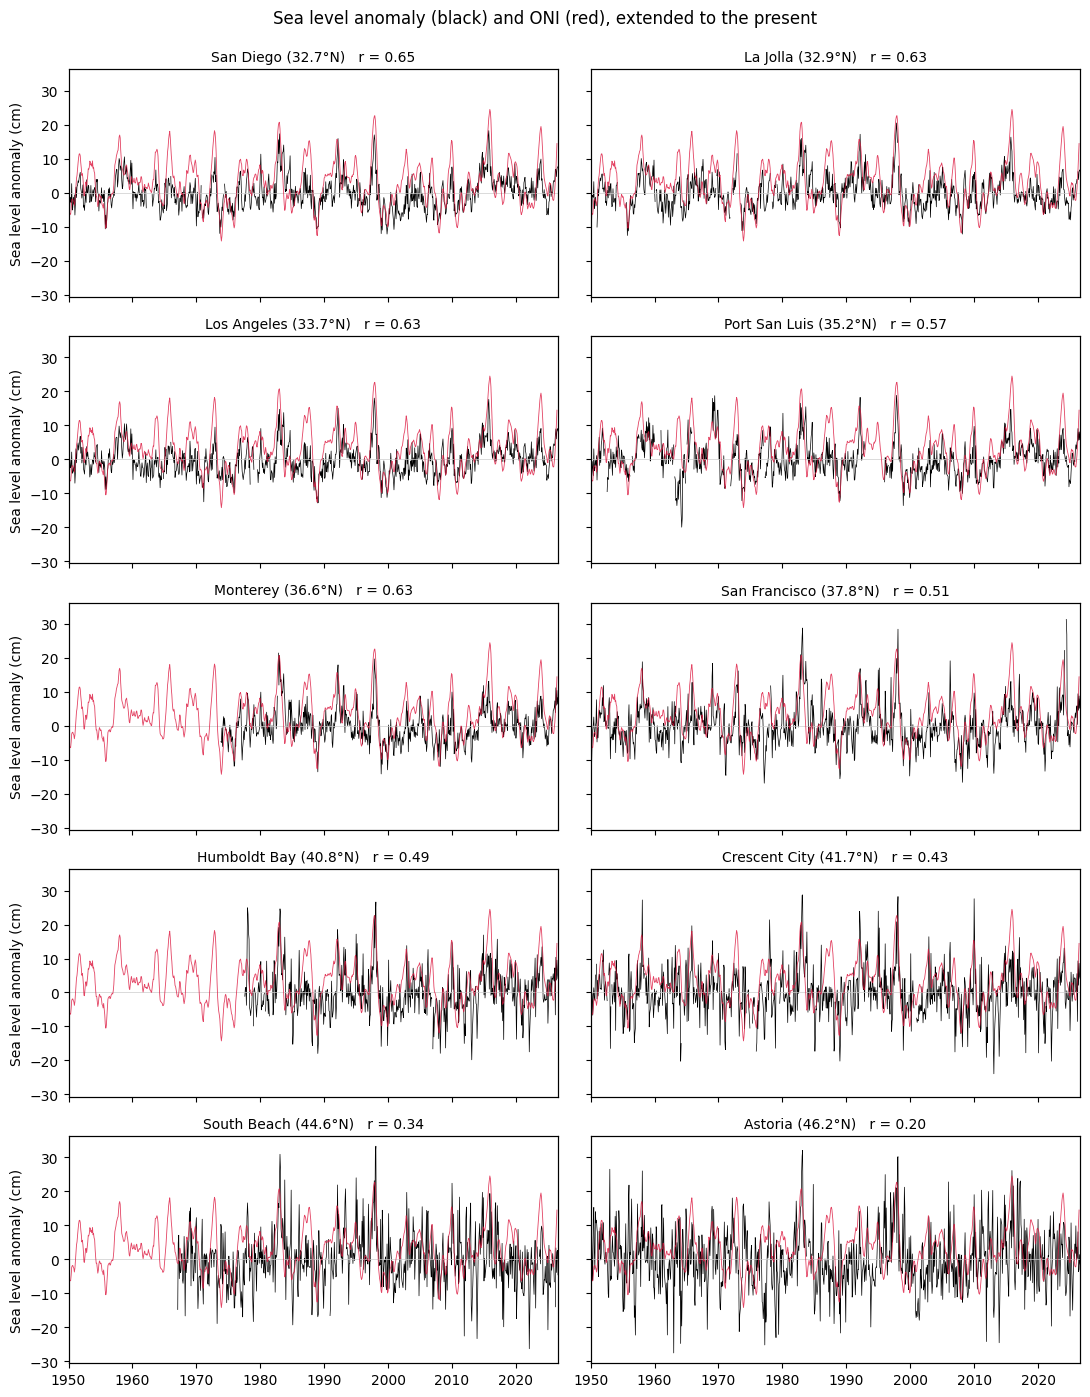

In [12]:
fig, axes = plt.subplots(5, 2, figsize=(11, 14), sharex=True, sharey=True)
for ax, rec in zip(axes.flat, records):
    sl = rec["sl"]["1950":]
    ax.plot(sl.index, sl, color="k", lw=0.5)
    ax.axhline(0, color="0.8", lw=0.5)
    ax2 = ax.twinx()
    ax2.plot(oni.index, oni, color="crimson", lw=0.6, alpha=0.8)
    ax2.set_ylim(-4, 4)              # same ONI scale in every panel
    ax2.set_yticks([])               # tabled once below, not ten times
    ax.set_title(f"{rec['site']} ({rec['lat']:.1f}°N)   r = {rec['r']:.2f}",
                 fontsize=10)
    ax.set_xlim(pd.Timestamp("1950-01-01"), sl.index[-1])
for ax in axes[:, 0]:
    ax.set_ylabel("Sea level anomaly (cm)")
fig.suptitle("Sea level anomaly (black) and ONI (red), extended to the present",
             y=0.995)
fig.tight_layout()
plt.show()

And the scatter clouds on shared axes, one point per shared month.

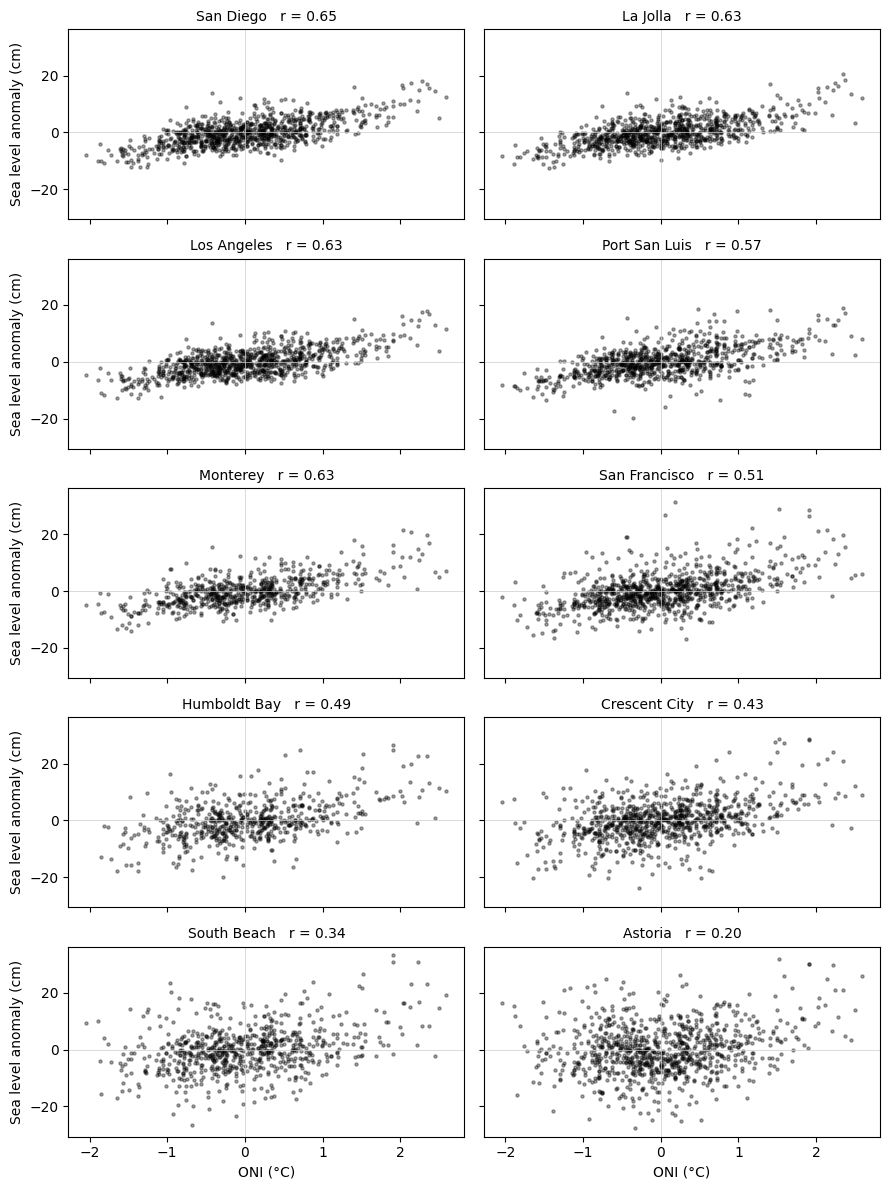

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(9, 12), sharex=True, sharey=True)
for ax, rec in zip(axes.flat, records):
    both = rec["both"]
    ax.scatter(both["ONI"], both["sl"], s=5, alpha=0.35, color="k")
    ax.axhline(0, color="0.8", lw=0.5)
    ax.axvline(0, color="0.8", lw=0.5)
    ax.set_title(f"{rec['site']}   r = {rec['r']:.2f}", fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel("Sea level anomaly (cm)")
for ax in axes[-1, :]:
    ax.set_xlabel("ONI (°C)")
fig.tight_layout()
plt.show()

The alongshore story in one frame: correlation against latitude. The tropical
signal fades poleward — r falls from 0.65 at San Diego to 0.20 at Astoria —
while the regression slope holds near 4 cm/°C until Oregon. What weakens r is
not the El Niño response shrinking but the storm-driven variance around it
growing, which the scatter grids above show directly.

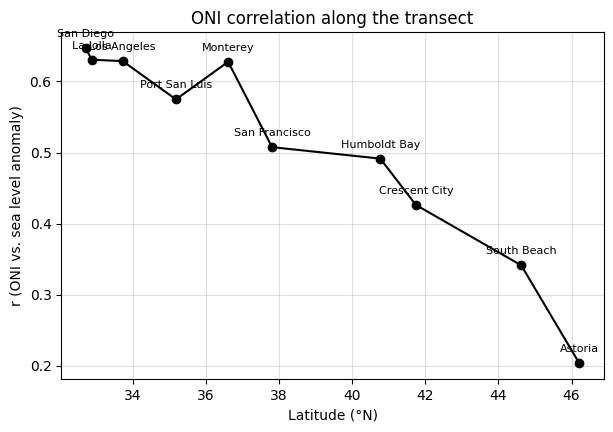

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
lats = [rec["lat"] for rec in records]
rs = [rec["r"] for rec in records]
ax.plot(lats, rs, "o-", color="k", ms=6)
for rec in records:
    ax.annotate(rec["site"], (rec["lat"], rec["r"]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("r (ONI vs. sea level anomaly)")
ax.set_title("ONI correlation along the transect")
ax.grid(alpha=0.4)
plt.show()

## Data notes

ONI from the NOAA Climate Prediction Center
([oni.ascii.txt](https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt), ERSSTv5
Niño 3.4 anomalies, centered 30-year base periods). UHSLC daily tide gauge data
(Caldwell, Merrifield, and Thompson 2015, doi:10.7289/V5V40S7W), extended to the
present with NOAA CO-OPS verified monthly means plus a provisional current-month
estimate; raw files stay in `data/raw/` and out of Git. The finished analysis:
`reference/14_el_nino_oni_correlation_complete.ipynb`.